In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
from scipy.integrate import cumulative_trapezoid

from src.r_bp import fit_R_BP_marginals_until_t
from src.transform import X_to_U
from src.lag import lagged_k_U
from src.copula import (
    fit_conditional_vines,
    conditional_vine_copula_cdf,
    estimate_gaussian_clayton_gas,
    compute_time_varying_copula_paths,
    gaussian_copula_log_density,
    clayton_copula_log_density
)
from src.conditional_density import (
    build_u_tilde_data,
    conditional_marginal_all
)
from src.predictive_density import predictive_density
from src.R_BP_james import fit_R_BP_marginals, fit_R_BP_marginals_observed


In [2]:
import importlib
import src.R_BP_james

importlib.reload(src.R_BP_james)

<module 'src.R_BP_james' from '/Users/chaeyunkim/Desktop/time varying copula /src/R_BP_james.py'>

In [3]:
# ============================================================
# 1. James가 사용한 MVN 데이터 생성
# ============================================================

np.random.seed(1234)  # seed for the random generator
n = 300               # number of observations
d = 4                 # the dimension

mean = 1 + np.random.normal(size=d)       # mean vector
cov = np.random.normal(size=(d, d))       # covariance matrix
cov = np.dot(cov.transpose(), cov)        # make it non-negative definite

print(cov, cov[1:, 1:], cov[0, 1:])

x = np.random.multivariate_normal(mean, cov, n)
test_point = np.random.multivariate_normal(mean, cov, 1)

print("x shape:", x.shape)
print("test_point shape:", test_point.shape)


[[ 1.59271386 -2.48417931 -0.38417425 -0.15093703]
 [-2.48417931  9.98573908 -0.75938116 -3.24080217]
 [-0.38417425 -0.75938116  3.91854106 -1.45078951]
 [-0.15093703 -3.24080217 -1.45078951  3.78204036]] [[ 9.98573908 -0.75938116 -3.24080217]
 [-0.75938116  3.91854106 -1.45078951]
 [-3.24080217 -1.45078951  3.78204036]] [-2.48417931 -0.38417425 -0.15093703]
x shape: (300, 4)
test_point shape: (1, 4)


In [4]:
# ============================================================
# 2. 학습 데이터와 test point 분리
# ============================================================

t = n

# James가 생성한 300개 MVN 관측값
X_train = x

# density를 계산할 별도의 test point
X_target = test_point
y = X_target[0]

print("X_train shape:", X_train.shape)
print("X_target shape:", X_target.shape)
print("y:", y)


X_train shape: (300, 4)
X_target shape: (1, 4)
y: [-0.31740881  4.3498564   4.00755888 -1.16003172]


In [5]:
# ============================================================
# 3-1. 각 변수의 R-BP marginal PDF와 CDF 추정 - 내 코드
# ============================================================

rho_grid = np.linspace(0.01, 0.99, 50)

(x_grids_t,
 p0_grids_t,
 P0_grids_t,
 rho_hats_t,
 p_grids_t,
 P_grids_t) = fit_R_BP_marginals_until_t( X_train=X_train,
                                          rho_grid=rho_grid)

print("Estimated R-BP rho:")
print(rho_hats_t)

# ============================================================
# 4. X 데이터를 uniform 데이터 U로 변환
# ============================================================

U_train_t = X_to_U( X=X_train,
                    x_grids=x_grids_t,
                    P_grids=P_grids_t )

print("U_train_t shape:", U_train_t.shape)
print("U range:", U_train_t.min(), U_train_t.max())

Estimated R-BP rho:
[np.float64(0.21000000000000002), np.float64(0.99), np.float64(0.85), np.float64(0.99)]
U_train_t shape: (300, 4)
U range: 0.0012791844680957807 0.9986878485654302


In [6]:
# ============================================================
# 3-2. 각 변수의 R-BP marginal PDF와 CDF 추정 및 U 변환- james
# ============================================================


(x_grids,
 p0_grids,
 P0_grids,
 rhos,
 p_grids,
 P_grids,
 Us) = fit_R_BP_marginals_observed(X_train=X_train, n_grid=1000)

print("Estimated R-BP rho:")
print(rhos)

Estimated R-BP rho:
[0.79559215 0.00094385 0.70045859 0.614427  ]


In [ ]:
print(Us.shape)

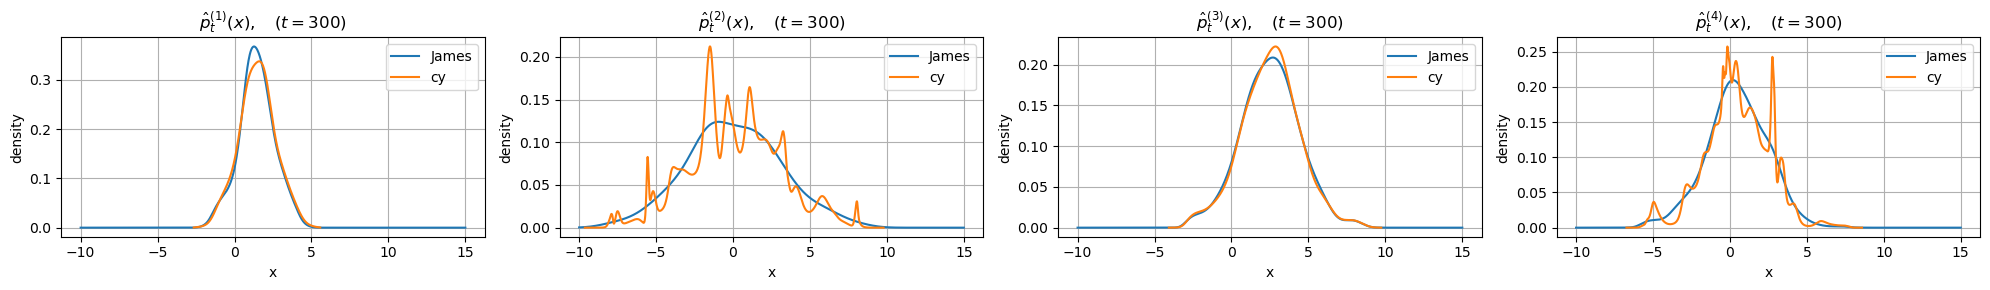

In [7]:
fig, axes = plt.subplots(1, d, figsize=(5 * d, 3))

for j in range(d):
    axes[j].plot(x_grids[j], p_grids[j], label="James")
    axes[j].plot(x_grids_t[j], p_grids_t[j], label="cy")
    axes[j].set_title(rf"$\hat p_{{t}}^{{({j+1})}}(x),\quad (t={t})$")
    axes[j].set_xlabel("x")
    axes[j].set_ylabel("density")
    axes[j].grid(True)
    axes[j].legend()

plt.tight_layout()
plt.show()


여기서 부터는 james 코드로 만든 R-BP 사용해서 나온 값 사용했음 


-
-
-
-
-
-
-
-
-
-
-
-
-
-










In [ ]:
'''
# ============================================================
# 5. 원본과 동일하게 3개 lag 조건변수 생성
# ============================================================
k = 3

U_condition_train, U_target_train = lagged_k_U(
    U=Us,
    k=k
)

print("U_condition_train shape:", U_condition_train.shape)
print("U_target_train shape:", U_target_train.shape)


# test point 예측에 사용할 최근 3개 lag
#
# d=4, k=3이므로 총 12개 조건변수:
# [U1_(t-2), U1_(t-1), U1_t,
#  U2_(t-2), U2_(t-1), U2_t,
#  U3_(t-2), U3_(t-1), U3_t,
#  U4_(t-2), U4_(t-1), U4_t]

u_condition_pred = Us[-k:, :].T.reshape(-1)

print("u_condition_pred:")
print(u_condition_pred)

# ============================================================
# 6. 각 변수의 conditional vine copula 추정
# ============================================================

vines_t = fit_conditional_vines(
    U_condition=U_condition_train,
    U_target=U_target_train
)

print("Number of fitted vines:", len(vines_t))

In [8]:
# 이미 계산된 x_grids와 P_grids를 사용
# R-BP를 다시 적합하는 것이 아님
Px = X_to_U(X=X_train, x_grids=x_grids, P_grids=P_grids)

print("Us shape:", Us.shape)  # (300, 4)
print("Px shape:", Px.shape)  # (300, 4)

Us shape: (300, 4)
Px shape: (300, 4)


In [9]:
# Us[i,j] = P_(i-1)(X_ij)   # R-BP가 순차적으로 돌 때 만들어진 값
# Px[i,j] = P_n(X_ij)       # 최종 R-BP CDF로 모든 X를 변환한 값

# ============================================================
# lag 없이 네 conditional vine 적합
# ============================================================

n, d = Px.shape

vines_t = []
condition_indices = []

for j in range(d):

    # j번째 변수를 제외한 같은 시점의 나머지 변수
    other = np.delete(np.arange(d), j)

    vine_j = fit_conditional_vines( U_condition=Px[:, other], U_target=Px[:, j:j+1])[0]

    vines_t.append(vine_j)
    condition_indices.append(other)

print("Number of fitted vines:", len(vines_t))

Number of fitted vines: 4


In [10]:
vines_t

[<pyvinecopulib.Vinecop> Vinecop model with 4 variables
 tree edge conditioned variables conditioning variables var_types   family rotation   parameters  df   tau 
    1    1                  1, 2                             c, c Gaussian        0        -0.61 1.0 -0.42 
    1    2                  2, 4                             c, c Gaussian        0        -0.52 1.0 -0.34 
    1    3                  3, 4                             c, c Gaussian        0        -0.46 1.0 -0.30 
    2    1                  1, 4                      2      c, c  Student        0 -0.61, 10.18 2.0 -0.41 
    2    2                  2, 3                      4      c, c Gaussian        0        -0.39 1.0 -0.26 
    3    1                  1, 3                   4, 2      c, c Gaussian        0        -0.84 1.0 -0.63 ,
 <pyvinecopulib.Vinecop> Vinecop model with 4 variables
 tree edge conditioned variables conditioning variables var_types   family rotation   parameters  df   tau 
    1    1             

In [11]:
# ============================================================
# 3개 그래프
#
# 1. Conditional marginal PDF
# 2. Conditional marginal CDF
# 3. Conditional vine copula density
#
# Target:
# X1 | X2, X3, X4
# ============================================================

eps = 1e-6

# 첫 번째 변수를 target으로 설정
j = 0

# X1을 제외한 변수 인덱스
# [1, 2, 3] = X2, X3, X4
other = condition_indices[j]

# test point
y = test_point[0]

# test point를 최종 James R-BP CDF로 변환
u_test = X_to_U(X=test_point, x_grids=x_grids, P_grids=P_grids)[0]
u_test = np.clip(u_test, eps, 1 - eps)

# X2, X3, X4의 PIT를 고정
u_condition = np.clip(u_test[other],eps, 1 - eps)

print("Target variable:")
print("X1")

print("Conditioning variables:")
print("X2, X3, X4")

print("Conditioning PIT:")
print(u_condition)


# ============================================================
# 1. Conditional vine copula PDF
# ============================================================

# X1의 R-BP CDF grid
u_grid = np.clip(P_grids[j], eps, 1 - eps)

# X1의 R-BP PDF grid
p_marginal = p_grids[j]

# c(u1, u2, u3, u4)의 입력
numerator_inputs = np.column_stack([ u_grid, np.tile(u_condition, (len(u_grid), 1))])

# Joint vine copula density
numerator = vines_t[j].pdf(numerator_inputs)


# Conditional density의 정규화 분모 계산
s_grid = np.linspace(eps,1 - eps,500)

denominator_inputs = np.column_stack([ s_grid, np.tile( u_condition, (len(s_grid), 1) )])

denominator_values = vines_t[j].pdf(denominator_inputs)

denominator = np.trapezoid(denominator_values, s_grid)
denominator = max(denominator,1e-12)

# James의 pdf_vals에 해당
conditional_copula_pdf = numerator / denominator
# James의 pdf_vals * u_1에 해당
conditional_marginal_pdf = p_marginal * conditional_copula_pdf

# ============================================================
# 2. Conditional vine copula CDF
# ============================================================

# uniform s_grid에서 conditional copula PDF
conditional_copula_pdf_s = (denominator_values/ denominator)

# PDF를 적분하여 conditional CDF 계산
conditional_copula_cdf_s = cumulative_trapezoid( conditional_copula_pdf_s, s_grid, initial=0.0)

# 마지막 값이 정확히 1이 되도록 정규화
conditional_copula_cdf_s = ( conditional_copula_cdf_s / conditional_copula_cdf_s[-1])

# X1의 R-BP CDF grid 위치에서 conditional CDF 계산
conditional_marginal_cdf = np.interp( u_grid, s_grid, conditional_copula_cdf_s)


# ============================================================
# 3. True MVN conditional distribution
#
# X1 | X2, X3, X4
# ============================================================

cov_other = cov[np.ix_(other, other)]

cov_j_other = cov[j, other]

difference =  y[other] - mean[other]


# True conditional mean
true_cond_mean = mean[j] + cov_j_other @ np.linalg.solve(cov_other, difference)
# True conditional variance
true_cond_var = cov[j, j] - cov_j_other @ np.linalg.solve(cov_other, cov[other, j])
# scipy norm의 scale에는 표준편차를 입력
true_cond_sd = np.sqrt(max(true_cond_var, 1e-12))


# True conditional PDF
true_cond_pdf = norm.pdf(x_grids[j], loc=true_cond_mean, scale=true_cond_sd)
# True conditional CDF
true_cond_cdf = norm.cdf(x_grids[j], loc=true_cond_mean, scale=true_cond_sd)



print("True conditional mean:")
print(true_cond_mean)

print("True conditional variance:")
print(true_cond_var)

print("True conditional standard deviation:")
print(true_cond_sd)

Target variable:
X1
Conditioning variables:
X2, X3, X4
Conditioning PIT:
[0.9168891  0.79308783 0.18865278]
True conditional mean:
-0.22990182398548176
True conditional variance:
0.15285083733818072
True conditional standard deviation:
0.3909614269185398


/var/folders/hy/qt13bysn77s0113553fdpvhh0000gn/T/ipykernel_60991/3181996578.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


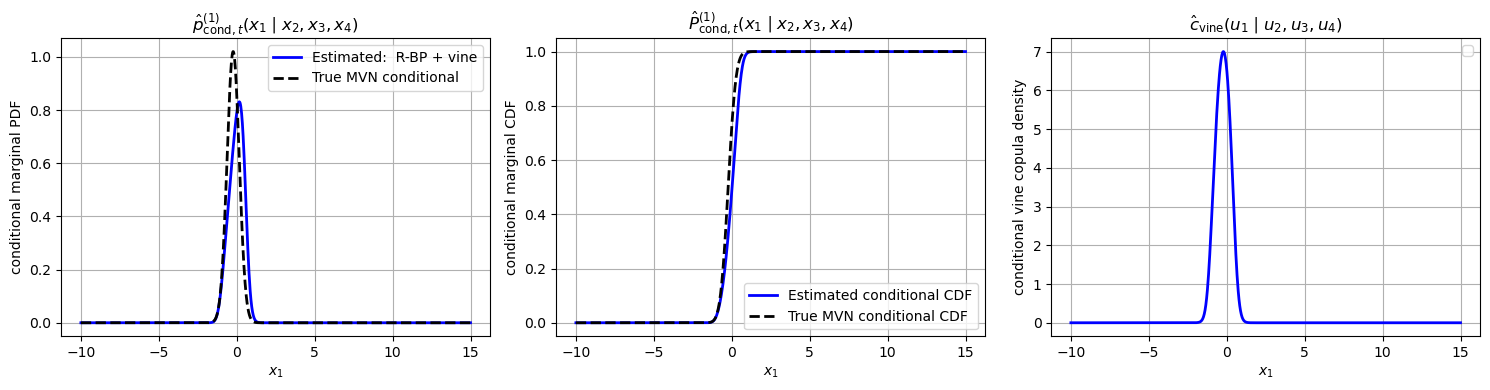

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


# ------------------------------------------------------------
# 왼쪽: Conditional marginal PDF
# ------------------------------------------------------------

axes[0].plot(x_grids[j], conditional_marginal_pdf, color="blue", linewidth=2, label="Estimated:  R-BP + vine")

axes[0].plot(x_grids[j], true_cond_pdf, color="black", linestyle="--", linewidth=2, label="True MVN conditional")

axes[0].set_title(r"$\hat p_{\mathrm{cond},t}^{(1)}" 
                  r"(x_1\mid x_2,x_3,x_4)$")

axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel("conditional marginal PDF")
axes[0].grid(True)
axes[0].legend()


# ------------------------------------------------------------
# 가운데: Conditional marginal CDF
# ------------------------------------------------------------

axes[1].plot(x_grids[j],conditional_marginal_cdf,color="blue",linewidth=2,label="Estimated conditional CDF")

axes[1].plot(x_grids[j], true_cond_cdf, color="black", linestyle="--", linewidth=2, label="True MVN conditional CDF")

axes[1].set_title(r"$\hat P_{\mathrm{cond},t}^{(1)}" r"(x_1\mid x_2,x_3,x_4)$")

axes[1].set_xlabel(r"$x_1$")
axes[1].set_ylabel("conditional marginal CDF")
axes[1].grid(True)
axes[1].legend()


# ------------------------------------------------------------
# 오른쪽: Conditional vine copula density만
# ------------------------------------------------------------

axes[2].plot(x_grids[j], conditional_copula_pdf, color="blue", linewidth=2)

axes[2].set_title(r"$\hat c_{\mathrm{vine}}"r"(u_1\mid u_2,u_3,u_4)$")

axes[2].set_xlabel(r"$x_1$")
axes[2].set_ylabel("conditional vine copula density")
axes[2].grid(True)
axes[2].legend()


plt.tight_layout()
plt.show()